In [1]:
from datasets import load_dataset
import pandas as pd
import re

dataset = load_dataset("Yelp/yelp_review_full")
df = pd.DataFrame(dataset['train'])
print(df.shape)

(650000, 2)


In [2]:
def map_sentiment(label):
    if label <= 1:
        return 'negative'
    elif label == 2:
        return 'neutral'
    else:
        return 'positive'

df['sentiment'] = df['label'].apply(map_sentiment)
df['sentiment'].value_counts()

sentiment
positive    260000
negative    260000
neutral     130000
Name: count, dtype: int64

In [3]:
from sklearn.model_selection import train_test_split

df_sample, _ = train_test_split(
    df, 
    train_size=30000, 
    stratify=df['sentiment'], 
    random_state=42
)

df_sample['sentiment'].value_counts()

sentiment
positive    12000
negative    12000
neutral      6000
Name: count, dtype: int64

In [4]:
import re

def clean_text(text):
    text = text.lower()                          # lowercase
    text = re.sub(r'<.*?>', '', text)             # remove HTML tags
    text = re.sub(r'http\S+|www\S+', '', text)    # remove URLs
    text = re.sub(r'[^a-z\s]', '', text)          # remove punctuation/numbers
    text = re.sub(r'\s+', ' ', text).strip()      # collapse extra whitespace
    return text

df_sample['clean_text'] = df_sample['text'].apply(clean_text)
df_sample[['text', 'clean_text']].head()

,text,clean_text
140238,I'm a huge gelato/ice cream fan. When I can't ...,im a huge gelatoice cream fan when i cant have...
145786,Went to have dinner with my sister the other n...,went to have dinner with my sister the other n...
442375,BLOWIN IT!! Unorganized & just lost previously...,blowin it unorganized just lost previously loy...
364186,The bachelor of our party wanted beef Wellingt...,the bachelor of our party wanted beef wellingt...
141990,"Overrated.\n\nI had better, I don't get what's...",overratednni had better i dont get whats the h...


In [5]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'\\n', ' ', text)              # handle literal \n escape sequences
    text = re.sub(r'<.*?>', ' ', text)             # remove HTML tags
    text = re.sub(r'http\S+|www\S+', ' ', text)    # remove URLs
    text = re.sub(r'[^a-z\s]', ' ', text)          # replace punctuation/numbers with space (not delete)
    text = re.sub(r'\s+', ' ', text).strip()       # collapse extra whitespace
    return text

df_sample['clean_text'] = df_sample['text'].apply(clean_text)
df_sample[['text', 'clean_text']].head()

,text,clean_text
140238,I'm a huge gelato/ice cream fan. When I can't ...,i m a huge gelato ice cream fan when i can t h...
145786,Went to have dinner with my sister the other n...,went to have dinner with my sister the other n...
442375,BLOWIN IT!! Unorganized & just lost previously...,blowin it unorganized just lost previously loy...
364186,The bachelor of our party wanted beef Wellingt...,the bachelor of our party wanted beef wellingt...
141990,"Overrated.\n\nI had better, I don't get what's...",overrated i had better i don t get what s the ...


In [6]:
import nltk
nltk.download('stopwords')
nltk.download('punkt')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    tokens = word_tokenize(text)
    filtered = [word for word in tokens if word not in stop_words]
    return ' '.join(filtered)

df_sample['final_text'] = df_sample['clean_text'].apply(remove_stopwords)
df_sample[['clean_text', 'final_text']].head()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\PRADAKSHANA\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\PRADAKSHANA\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


,clean_text,final_text
140238,i m a huge gelato ice cream fan when i can t h...,huge gelato ice cream fan gelato next go cold ...
145786,went to have dinner with my sister the other n...,went dinner sister night stood entrance mins a...
442375,blowin it unorganized just lost previously loy...,blowin unorganized lost previously loyal custo...
364186,the bachelor of our party wanted beef wellingt...,bachelor party wanted beef wellington gordon r...
141990,overrated i had better i don t get what s the ...,overrated better get hype service rude chefs w...


In [7]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\PRADAKSHANA\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [8]:
df_sample[['clean_text', 'final_text']].head()

,clean_text,final_text
140238,i m a huge gelato ice cream fan when i can t h...,huge gelato ice cream fan gelato next go cold ...
145786,went to have dinner with my sister the other n...,went dinner sister night stood entrance mins a...
442375,blowin it unorganized just lost previously loy...,blowin unorganized lost previously loyal custo...
364186,the bachelor of our party wanted beef wellingt...,bachelor party wanted beef wellington gordon r...
141990,overrated i had better i don t get what s the ...,overrated better get hype service rude chefs w...


In [9]:
df_sample.to_csv('../data/processed/yelp_sample_cleaned.csv', index=False)
print("Saved!")

Saved!


In [10]:
import os
os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../data/raw', exist_ok=True)

In [11]:
df_sample.to_csv('../data/processed/yelp_sample_cleaned.csv', index=False)
print("Saved!")

Saved!


In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X = tfidf.fit_transform(df_sample['final_text'])
y = df_sample['sentiment']

print(X.shape)

(30000, 5000)


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    stratify=y, 
    random_state=42
)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (24000, 5000) Test: (6000, 5000)


In [14]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

print("Training complete")

Training complete


In [15]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       0.83      0.77      0.80      2400
     neutral       0.45      0.58      0.51      1200
    positive       0.82      0.77      0.79      2400

    accuracy                           0.73      6000
   macro avg       0.70      0.70      0.70      6000
weighted avg       0.75      0.73      0.74      6000



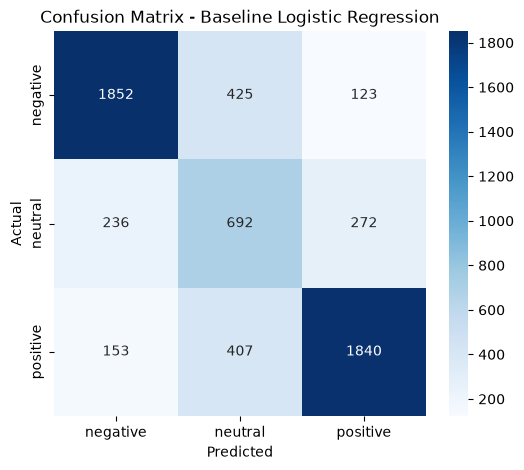

In [16]:
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Baseline Logistic Regression')
plt.show()

In [17]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(class_weight='balanced', max_iter=2000)
svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)
print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

    negative       0.80      0.80      0.80      2400
     neutral       0.45      0.45      0.45      1200
    positive       0.79      0.79      0.79      2400

    accuracy                           0.73      6000
   macro avg       0.68      0.68      0.68      6000
weighted avg       0.73      0.73      0.73      6000



In [18]:
tfidf_v2 = TfidfVectorizer(
    max_features=10000,      # more vocabulary
    ngram_range=(1,2),
    min_df=5,                # ignore words appearing in fewer than 5 reviews (noise)
    max_df=0.8                # ignore words appearing in >80% of reviews (too common to be useful)
)

X_v2 = tfidf_v2.fit_transform(df_sample['final_text'])

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_v2, y, test_size=0.2, stratify=y, random_state=42
)

svm_model2 = LinearSVC(class_weight='balanced', max_iter=2000)
svm_model2.fit(X_train2, y_train2)

y_pred_svm2 = svm_model2.predict(X_test2)
print(classification_report(y_test2, y_pred_svm2))

              precision    recall  f1-score   support

    negative       0.80      0.81      0.80      2400
     neutral       0.46      0.46      0.46      1200
    positive       0.81      0.79      0.80      2400

    accuracy                           0.73      6000
   macro avg       0.69      0.69      0.69      6000
weighted avg       0.73      0.73      0.73      6000



In [19]:
df_transformer, _ = train_test_split(
    df_sample, 
    train_size=6000, 
    stratify=df_sample['sentiment'], 
    random_state=42
)

df_transformer['sentiment'].value_counts()

sentiment
negative    2400
positive    2400
neutral     1200
Name: count, dtype: int64

In [20]:
label2id = {'negative': 0, 'neutral': 1, 'positive': 2}
id2label = {0: 'negative', 1: 'neutral', 2: 'positive'}

df_transformer['label_id'] = df_transformer['sentiment'].map(label2id)
df_transformer[['sentiment', 'label_id']].head()

,sentiment,label_id
108978,neutral,1
529676,negative,0
645283,positive,2
246663,negative,0
515802,negative,0


In [21]:
train_df, test_df = train_test_split(
    df_transformer, 
    test_size=0.2, 
    stratify=df_transformer['sentiment'], 
    random_state=42
)

print("Train:", train_df.shape, "Test:", test_df.shape)

Train: (4800, 6) Test: (1200, 6)


In [22]:
from transformers import DistilBertTokenizer

tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

def tokenize_function(texts):
    return tokenizer(
        list(texts), 
        padding=True, 
        truncation=True, 
        max_length=256,
        return_tensors='pt'
    )

train_encodings = tokenize_function(train_df['text'])
test_encodings = tokenize_function(test_df['text'])

print(train_encodings['input_ids'].shape)

torch.Size([4800, 256])


In [23]:
import torch

class SentimentDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

train_dataset = SentimentDataset(train_encodings, train_df['label_id'].tolist())
test_dataset = SentimentDataset(test_encodings, test_df['label_id'].tolist())

print(len(train_dataset), len(test_dataset))

4800 1200


In [24]:
from transformers import DistilBertForSequenceClassification

model_transformer = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased', 
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

print("Model loaded")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded


In [25]:
from transformers import TrainingArguments, Trainer
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        'accuracy': accuracy_score(labels, preds),
        'f1_macro': f1_score(labels, preds, average='macro')
    }

training_args = TrainingArguments(
    output_dir='../models/distilbert-checkpoints',
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    eval_strategy='epoch',
    save_strategy='epoch',
    logging_dir='../models/logs',
    logging_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro'
)

trainer = Trainer(
    model=model_transformer,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

print("Trainer ready")

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Trainer ready


In [26]:
pip install "accelerate>=1.1.0"

Note: you may need to restart the kernel to use updated packages.


In [28]:
!wmic OS get FreePhysicalMemory,TotalVisibleMemorySize /Value





FreePhysicalMemory=755396

TotalVisibleMemorySize=8104744







